<a href="https://colab.research.google.com/github/Somified/LeadRefine-Drug-likeliness/blob/main/drug_likeliness_ranking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Install RDKit in Colab
!pip install -q condacolab
import condacolab
condacolab.install()

!conda install -c conda-forge rdkit -y


✨🍰✨ Everything looks OK!
Channels:
 - conda-forge
Platform: linux-64
Solving environment: \ | / - \ done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.3
    latest version: 25.11.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [5]:
# Python imports
import sys

conda_site_packages_path = "/usr/local/lib/python3.11/site-packages"
if conda_site_packages_path not in sys.path:
    sys.path.append(conda_site_packages_path)

from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Draw


In [6]:
# Lipinski-style thresholds
RULES = {
    "molecular_weight": 500,
    "logp": 5,
    "hbd": 5,
    "hba": 10,
    "tpsa": 140,
    "rotatable_bonds": 10
}

# Meaning of violations
VIOLATION_MEANINGS = {
    "molecular_weight": {
        "category": "size",
        "issue": "Molecule may be too large for oral absorption"
    },
    "logp": {
        "category": "lipophilicity",
        "issue": "Excessive hydrophobicity may reduce solubility"
    },
    "hbd": {
        "category": "polarity",
        "issue": "Too many hydrogen bond donors"
    },
    "hba": {
        "category": "polarity",
        "issue": "Too many hydrogen bond acceptors"
    },
    "tpsa": {
        "category": "polarity",
        "issue": "High polar surface area may hinder permeability"
    },
    "rotatable_bonds": {
        "category": "flexibility",
        "issue": "High molecular flexibility may reduce binding efficiency"
    }
}

# Optimization suggestions
SUGGESTION_MAP = {
    "size": [
        "Remove bulky substituents",
        "Simplify ring systems"
    ],
    "lipophilicity": [
        "Add polar functional groups such as alcohols or carboxylic acids",
        "Reduce hydrophobic substituents"
    ],
    "polarity": [
        "Reduce excessive hydrogen bond donors or acceptors",
        "Replace highly polar groups with bioisosteres"
    ],
    "flexibility": [
        "Reduce the number of rotatable bonds",
        "Introduce ring systems to increase rigidity"
    ]
}


In [42]:
def analyze_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return {
            "smiles": smiles,
            "valid": False,
            "error": "Invalid SMILES"
        }

    # ---- Property calculation ----
    properties = {
        "molecular_weight": Descriptors.MolWt(mol),
        "logp": Descriptors.MolLogP(mol),
        "hbd": Lipinski.NumHDonors(mol),
        "hba": Lipinski.NumHAcceptors(mol),
        "tpsa": Descriptors.TPSA(mol),
        "rotatable_bonds": Lipinski.NumRotatableBonds(mol)
    }

    # ---- Lipinski violations ----
    violations = []
    for prop, limit in RULES.items():
        if properties[prop] > limit:
            v = {
                "property": prop,
                "value": properties[prop],
                "limit": limit
            }
            meaning = VIOLATION_MEANINGS[prop]
            v["category"] = meaning["category"]
            v["issue"] = meaning["issue"]
            v["suggestions"] = SUGGESTION_MAP.get(v["category"], [])
            violations.append(v)

    # ---- Drug-likeness score ----
    score = 100
    score -= 15 * len(violations)

    for prop, limit in RULES.items():
        deviation = max(0, properties[prop] - limit)
        score -= deviation * 0.1

    score = max(score, 0)

    # ---- Severe red flags ----
    severe_flags = 0

    if properties["logp"] > 6:
        severe_flags += 1

    if properties["rotatable_bonds"] > 12:
        severe_flags += 1

    if properties["tpsa"] < 10:
        severe_flags += 1

    # ---- Hard rejection rules (scaffold-level) ----
    reject_reason = None

    if properties["molecular_weight"] < 150:
        reject_reason = "Too small to be a viable drug scaffold"

    if properties["hbd"] == 0 and properties["hba"] == 0:
        reject_reason = "No functional groups for target binding"

    # ---- Physicochemical status ----
    if len(violations) == 0 and score >= 85:
        physchem_status = "OPTIMAL"

    elif len(violations) <= 1 and score >= 75 and severe_flags == 0:
        physchem_status = "NEAR_OPTIMAL"

    elif score >= 50 and severe_flags <= 1:
        physchem_status = "POOR"

    else:
        physchem_status = "WEAK"

    # ---- Final decision ----
    if reject_reason is not None:
        decision = "REJECT"
    else:
        decision = "ACCEPT"

    return {
        "smiles": smiles,
        "valid": True,
        "mol": mol,
        "properties": properties,
        "violations": violations,
        "num_violations": len(violations),
        "score": round(score, 2),
        "physchem_status": physchem_status,
        "decision": decision,
        "reject_reason": reject_reason
    }


In [43]:
def analyze_multiple_smiles(smiles_list):
    results = []
    for s in smiles_list:
        results.append(analyze_smiles(s))
    return results

In [44]:

def rank_molecules(results):
    valid = [r for r in results if r.get("valid")]
    ranked = sorted(
        valid,
        key=lambda x: (x["score"], -x["num_violations"]),
        reverse=True
    )
    return ranked


In [45]:
def dataset_decision(results):
    statuses = [r["status"] for r in results if r["valid"]]

    if all(s == "UNSUITABLE" for s in statuses):
        return "ALL_UNSUITABLE"
    if all(s == "OPTIMAL" for s in statuses):
        return "ALL_OPTIMAL"
    return "MIXED"


In [46]:
def show_molecules(results):
    mols = [r["mol"] for r in results if r["valid"]]
    legends = [f"{r['status']} | Score: {r['score']}" for r in results if r["valid"]]
    return Draw.MolsToGridImage(mols, molsPerRow=3, legends=legends, subImgSize=(200,200))

In [50]:
smiles_list = [
    "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O",
    "CC(=O)Oc1ccccc1C(=O)O",   # aspirin
    "CCCCCCCCCCCCCCCC",
    "c1ccc(cc1)Cc2ccccc2",
    "CCN"
]

results = analyze_multiple_smiles(smiles_list)
ranked = rank_molecules(results)
decision = dataset_decision(ranked)

In [51]:
def dataset_decision(results):
    decisions = [r["decision"] for r in results if r["valid"]]

    if all(d == "REJECT" for d in decisions):
        return "ALL_REJECTED"

    if all(d == "ACCEPT" for d in decisions):
        return "ALL_ACCEPTED"

    return "MIXED"



In [52]:
results = analyze_multiple_smiles(smiles_list)
ranked = rank_molecules(results)
decision = dataset_decision(ranked)

print("DATASET DECISION:", decision)


DATASET DECISION: MIXED


In [56]:
for i, r in enumerate(ranked, 1):
    print(f"\nRank {i}: {r['smiles']}")

    # ---- Physicochemical summary ----
    if r["physchem_status"] == "OPTIMAL":
        print("Physicochemical assessment: OPTIMAL (satisfies key drug-likeness criteria)")
    elif r["physchem_status"] == "NEAR_OPTIMAL":
        print("Physicochemical assessment: NEAR-OPTIMAL (minor issues detected)")
    elif r["physchem_status"] == "POOR":
        print("Physicochemical assessment: POOR (multiple weaknesses present)")
    else:
        print("Physicochemical assessment: WEAK")

    print("Final decision:", r["decision"])
    print("Drug-likeness score:", r["score"])

    # ---- Properties ----
    print("Properties:")
    for k, v in r["properties"].items():
        print(f"  {k}: {v}")

    # ---- Violations ----
    if r["violations"]:
        print("Rule violations detected:")
        for v in r["violations"]:
            print(f" - {v['property']} exceeded (value: {v['value']} > limit: {v['limit']})")
            print(f"   Issue: {v['issue']}")
            for s in v["suggestions"]:
                print(f"   Suggested improvement: {s}")
    else:
        print("Rule violations: None (passes Lipinski-style rules)")

    # ---- Rejection explanation ----
    if r["decision"] == "REJECT":
        print("Rejection reason:", r["reject_reason"])

    # ---- Acceptance note ----
    if r["decision"] == "ACCEPT" and r["physchem_status"] == "OPTIMAL":
        print("✔ This molecule is physicochemically well-balanced and suitable for further consideration.")



Rank 1: CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O
Physicochemical assessment: OPTIMAL (satisfies key drug-likeness criteria)
Final decision: ACCEPT
Drug-likeness score: 100.0
Properties:
  molecular_weight: 206.28499999999997
  logp: 3.073200000000001
  hbd: 1
  hba: 1
  tpsa: 37.3
  rotatable_bonds: 4
Rule violations: None (passes Lipinski-style rules)
✔ This molecule is physicochemically well-balanced and suitable for further consideration.

Rank 2: CC(=O)Oc1ccccc1C(=O)O
Physicochemical assessment: OPTIMAL (satisfies key drug-likeness criteria)
Final decision: ACCEPT
Drug-likeness score: 100.0
Properties:
  molecular_weight: 180.15899999999996
  logp: 1.3101
  hbd: 1
  hba: 3
  tpsa: 63.60000000000001
  rotatable_bonds: 2
Rule violations: None (passes Lipinski-style rules)
✔ This molecule is physicochemically well-balanced and suitable for further consideration.

Rank 3: c1ccc(cc1)Cc2ccccc2
Physicochemical assessment: OPTIMAL (satisfies key drug-likeness criteria)
Final decision: REJECT
Drug-

In [57]:
if decision == "ALL_REJECTED":
    print("\n🚫 All molecules were rejected.")
    print("Recommendation: Move to a new chemical scaffold.")

elif decision == "ALL_ACCEPTED":
    print("\n✅ All molecules are acceptable.")
    print("Top-ranked molecule is the most optimal candidate.")

else:
    print("\n⚖ Mixed results detected.")
    print("Some molecules are viable, others are not.")
    print("Near-optimal molecules may be improved.")


⚖ Mixed results detected.
Some molecules are viable, others are not.
Near-optimal molecules may be improved.


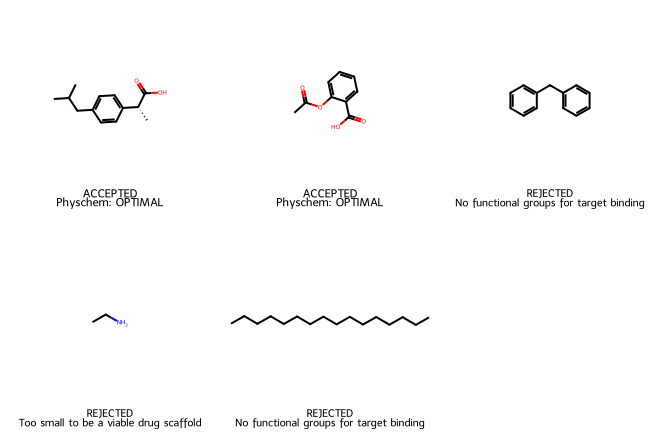

In [59]:
from rdkit.Chem import Draw

mols = []
legends = []

for r in ranked:
    if not r["valid"]:
        continue

    mols.append(r["mol"])

    if r["decision"] == "ACCEPT":
        legend = f"ACCEPTED\nPhyschem: {r['physchem_status']}"
    else:
        if r["reject_reason"]:
            legend = f"REJECTED\n{r['reject_reason']}"
        else:
            legend = f"REJECTED\nPhyschem: {r['physchem_status']}"

    legends.append(legend)

Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    legends=legends,
    subImgSize=(220, 220)
)